In [15]:
train_file = "/kaggle/input/competitions/sem-eval-2026-task-13-subtask-a/Task_A/train.parquet"
val_file = "/kaggle/input/competitions/sem-eval-2026-task-13-subtask-a/Task_A/validation.parquet"
test_file = "/kaggle/input/competitions/sem-eval-2026-task-13-subtask-a/Task_A/test.parquet"

In [31]:
import pandas as pd

# Read parquet
train_df = pd.read_parquet(train_file)
val_df = pd.read_parquet(val_file)
test_df = pd.read_parquet(test_file)

# Quick preview
print("Train shape:", train_df.shape)
print("Trains columns:", train_df.columns.tolist())

print("Val shape:", val_df.shape)
print("Val columns:", val_df.columns.tolist())

print("Test shape:", test_df.shape)
print("Test columns:", test_df.columns.tolist())

Train shape: (500000, 4)
Trains columns: ['code', 'generator', 'label', 'language']
Val shape: (100000, 4)
Val columns: ['code', 'generator', 'label', 'language']
Test shape: (500000, 2)
Test columns: ['ID', 'code']


In [ ]:
from IPython.display import HTML, display
from pygments import highlight
from pygments.lexers import get_lexer_by_name, guess_lexer, TextLexer
from pygments.formatters import HtmlFormatter

def highlight_code(code: str, lang: str | None = None):
    code = "" if pd.isna(code) else str(code)
    try:
        lexer = get_lexer_by_name(lang) if lang else guess_lexer(code)
    except Exception:
        lexer = TextLexer()

    formatter = HtmlFormatter(
        style="material",
        noclasses=True,
        cssstyles="border-radius:10px; padding:12px 14px; font-size:13px; line-height:1.45;"
    )
    return highlight(code, lexer, formatter)

heads = train_df.sample(4, random_state=42)
for idx, row in heads.iterrows():
    print(f"Row {idx}, {row['generator']}:")
    display(HTML(highlight_code(row["code"], row.get("language", None))))

Shape: (500000, 4)
Columns: ['code', 'generator', 'label', 'language']
Row 62405, meta-llama/Llama-3.1-8B:


Row 263305, human:


Row 104038, human:


Row 313443, Qwen/Qwen2.5-Coder-7B:


# Explore Data

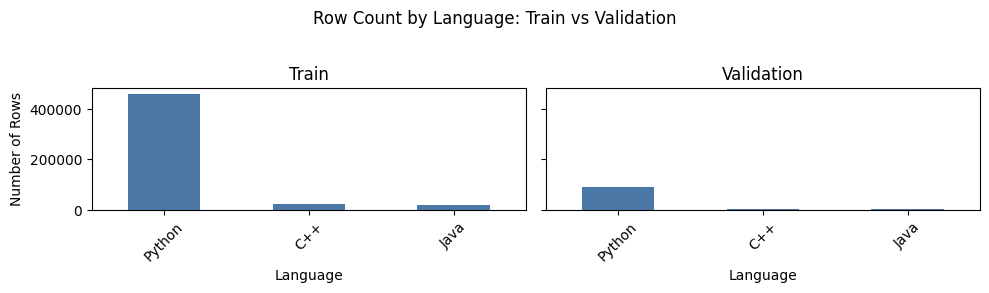

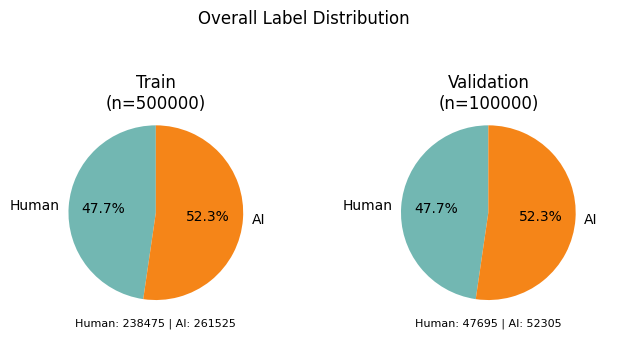

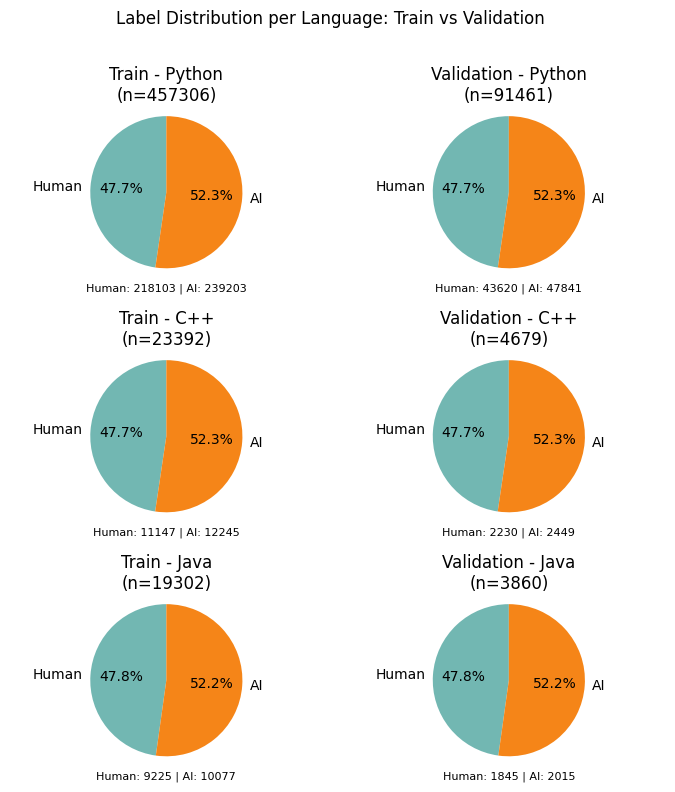

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# 0 = Human, 1 = AI
label_map = {0: "Human", 1: "AI"}

def prepare_label_df(df):
    out = df.copy()
    out["language"] = out["language"].fillna("unknown").astype(str)
    out["label_name"] = out["label"].map(label_map).fillna(out["label"].astype(str))
    return out

def label_counts(df):
    return df["label_name"].value_counts().reindex(["Human", "AI"]).fillna(0)

def pie_with_count_text(ax, counts, title):
    ax.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#72B7B2", "#F58518"]
    )
    ax.set_title(title)
    ax.axis("equal")
    ax.text(
        0,
        -1.2,
        f"Human: {int(counts.get('Human', 0))} | AI: {int(counts.get('AI', 0))}",
        ha="center",
        va="top",
        fontsize=8
    )

train_vis = prepare_label_df(train_df)
val_vis = prepare_label_df(val_df)

# 1) Bar chart: language counts (Train vs Validation side-by-side)
train_lang_counts = train_vis["language"].value_counts()
val_lang_counts = val_vis["language"].value_counts()

all_languages = (
    train_lang_counts.add(val_lang_counts, fill_value=0)
    .sort_values(ascending=False)
    .index
)
train_lang_counts = train_lang_counts.reindex(all_languages, fill_value=0)
val_lang_counts = val_lang_counts.reindex(all_languages, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 2.8), sharey=True)
for ax, counts, split_name in zip(
    axes,
    [train_lang_counts, val_lang_counts],
    ["Train", "Validation"]
):
    counts.plot(kind="bar", ax=ax, color="#4C78A8")
    ax.set_title(split_name)
    ax.set_xlabel("Language")
    ax.set_ylabel("Number of Rows")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Row Count by Language: Train vs Validation", y=1.03)
plt.tight_layout()
plt.show()

# 2) Pie chart: overall label distribution (Train vs Validation)
train_overall = label_counts(train_vis)
val_overall = label_counts(val_vis)

fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.2))
for ax, counts, split_name in zip(
    axes,
    [train_overall, val_overall],
    ["Train", "Validation"]
):
    pie_with_count_text(ax, counts, f"{split_name}\n(n={int(counts.sum())})")

plt.suptitle("Overall Label Distribution", y=1.05)
plt.tight_layout()
plt.show()

# 3) Pie chart: label distribution per language (Train vs Validation)
languages = list(all_languages)
fig, axes = plt.subplots(len(languages), 2, figsize=(7.0, 2.6 * len(languages)))

if len(languages) == 1:
    axes = [axes]

for i, lang in enumerate(languages):
    train_counts = label_counts(train_vis[train_vis["language"] == lang])
    val_counts = label_counts(val_vis[val_vis["language"] == lang])

    left_ax = axes[i][0] if len(languages) > 1 else axes[0]
    right_ax = axes[i][1] if len(languages) > 1 else axes[1]

    pie_with_count_text(
        left_ax,
        train_counts,
        f"Train - {lang}\n(n={int(train_counts.sum())})"
    )
    pie_with_count_text(
        right_ax,
        val_counts,
        f"Validation - {lang}\n(n={int(val_counts.sum())})"
    )

plt.suptitle("Label Distribution per Language: Train vs Validation", y=1.01)
plt.tight_layout()
plt.show()

## Token Size Comparison: Train vs Validation

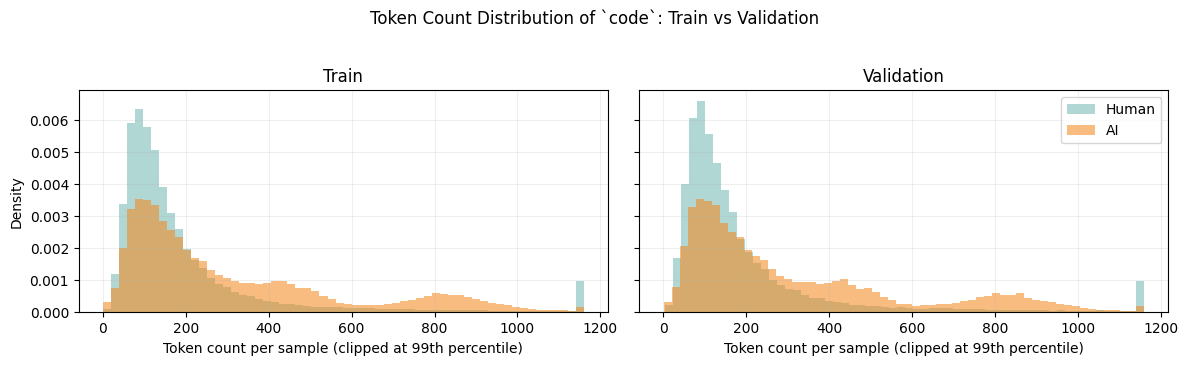

count    mean     std    25%    50%    75%      max
split      label_name                                                        
Train      AI          261525.0  310.26  261.73  114.0  209.0  431.0   2543.0
           Human       238475.0  215.08  456.54   85.0  128.0  208.0  54918.0
Validation AI           52305.0  310.32  262.48  114.0  210.0  430.0   1996.0
           Human        47695.0  214.03  439.16   85.0  128.0  207.0  24008.0

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Reuse tokenizer from previous section if available
if "TOKEN_PATTERN" not in globals():
    import re
    TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)

if "count_code_tokens" not in globals():
    def count_code_tokens(text):
        if text is None or (isinstance(text, float) and np.isnan(text)):
            return 0
        return len(TOKEN_PATTERN.findall(str(text)))

label_map = {0: "Human", 1: "AI"}

def prepare_token_df(df, split_name):
    out = df[["code", "label"]].copy()
    out["label_name"] = out["label"].map(label_map).fillna(out["label"].astype(str))
    out["token_count"] = out["code"].apply(count_code_tokens)
    out["split"] = split_name
    return out

train_token_df = prepare_token_df(train_df, "Train")
val_token_df = prepare_token_df(val_df, "Validation")

all_tokens = pd.concat([train_token_df, val_token_df], ignore_index=True)
clip_max = all_tokens["token_count"].quantile(0.99)
all_tokens["token_count_clipped"] = all_tokens["token_count"].clip(upper=clip_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True, sharey=True)
colors = {"Human": "#72B7B2", "AI": "#F58518"}
bins = 60

for ax, split_name in zip(axes, ["Train", "Validation"]):
    sub = all_tokens[all_tokens["split"] == split_name]
    for label_name in ["Human", "AI"]:
        vals = sub.loc[sub["label_name"] == label_name, "token_count_clipped"]
        if len(vals) == 0:
            continue
        ax.hist(
            vals,
            bins=bins,
            alpha=0.55,
            density=True,
            label=label_name,
            color=colors[label_name]
        )

    ax.set_title(f"{split_name}")
    ax.set_xlabel("Token count per sample (clipped at 99th percentile)")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Density")
axes[1].legend(loc="upper right")
plt.suptitle("Token Count Distribution of `code`: Train vs Validation", y=1.03)
plt.tight_layout()
plt.show()

comparison_summary = (
    all_tokens.groupby(["split", "label_name"])["token_count"]
    .describe()[["count", "mean", "std", "25%", "50%", "75%", "max"]]
    .round(2)
)
display(comparison_summary)